In [2]:
# ================================================================
# CELL 1: INSTALL LIBRARIES
# ================================================================

!pip install -q opencv-python-headless scikit-image \
    torch torchvision transformers scikit-learn \
    pandas matplotlib seaborn tqdm

In [3]:
# ================================================================
# CELL 2: IMPORT LIBRARIES
# ================================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from skimage import morphology
from skimage.filters import threshold_otsu

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

from google.colab import drive

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# ================================================================
# CELL 3: GOOGLE DRIVE
# ================================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ================================================================
# CELL 4: INPUT IMAGE PATHS
# ================================================================

image_paths = [

    "/content/drive/MyDrive/cancer_dataset/high/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%5.png",

    "/content/drive/MyDrive/cancer_dataset/high/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%7.png",

    "/content/drive/MyDrive/cancer_dataset/mild/1307.png",

    "/content/drive/MyDrive/cancer_dataset/moderate/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%6.png",

    "/content/drive/MyDrive/cancer_dataset/normal/1305.png",

    "/content/drive/MyDrive/cancer_dataset/normal/1306.png"
]


# ================================================================
# CHECK FILES
# ================================================================

for path in image_paths:

    if os.path.exists(path):
        print("✓ FOUND:", path)

    else:
        print("✗ NOT FOUND:", path)

✓ FOUND: /content/drive/MyDrive/cancer_dataset/high/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%5.png
✓ FOUND: /content/drive/MyDrive/cancer_dataset/high/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%7.png
✓ FOUND: /content/drive/MyDrive/cancer_dataset/mild/1307.png
✓ FOUND: /content/drive/MyDrive/cancer_dataset/moderate/Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%6.png
✓ FOUND: /content/drive/MyDrive/cancer_dataset/normal/1305.png
✓ FOUND: /content/drive/MyDrive/cancer_dataset/normal/1306.png


In [7]:
# ================================================================
# CELL 5: OUTPUT DIRECTORIES
# ================================================================

BASE_DIR = "/content/drive/MyDrive/cancer_pipeline"

DIRS = {

    "preprocessed":
        os.path.join(BASE_DIR, "01_preprocessed"),

    "normalized":
        os.path.join(BASE_DIR, "02_normalized"),

    "masks":
        os.path.join(BASE_DIR, "03_lung_masks"),

    "segmented":
        os.path.join(BASE_DIR, "04_segmented_lungs"),

    "features":
        os.path.join(BASE_DIR, "05_features"),

    "visualizations":
        os.path.join(BASE_DIR, "06_visualizations"),

    "embeddings":
        os.path.join(BASE_DIR, "07_embeddings"),

    "gradcam":
        os.path.join(BASE_DIR, "08_gradcam"),

    "results":
        os.path.join(BASE_DIR, "09_results")
}


for folder in DIRS.values():
    os.makedirs(folder, exist_ok=True)


print("Output folders created.")

Output folders created.


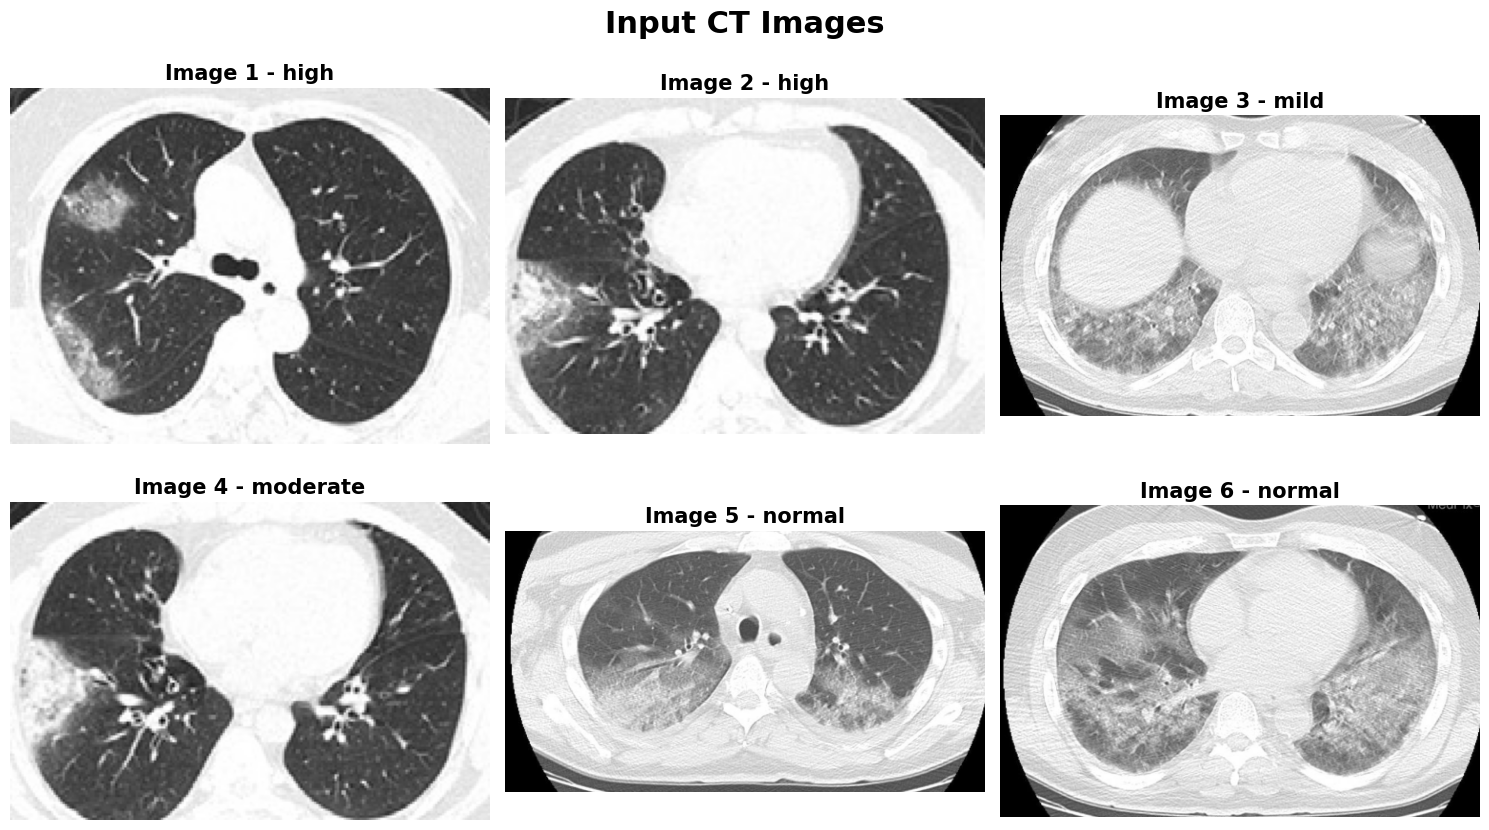

In [8]:
# ================================================================
# CELL 6: INPUT CT IMAGE VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, path in enumerate(image_paths):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(img)

    label = os.path.basename(
        os.path.dirname(path)
    )

    axes[i].set_title(
        f"Image {i+1} - {label}",
        fontsize=15,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Input CT Images",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [9]:
# ================================================================
# CELL 7: IMAGE LOADING
# ================================================================

IMG_SIZE = 512


def load_image(path):

    img = cv2.imread(path)

    if img is None:
        raise ValueError(
            f"Cannot read image: {path}"
        )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    return img


images = []

for path in image_paths:

    img = load_image(path)

    images.append(img)


print(
    "Loaded images:",
    len(images)
)

print(
    "Image shape:",
    images[0].shape
)

Loaded images: 6
Image shape: (512, 512, 3)


In [10]:
# ================================================================
# CELL 8: DENOISING
# ================================================================

def denoise_image(img):

    denoised = cv2.medianBlur(
        img,
        5
    )

    return denoised


denoised_images = []

for i, img in enumerate(images):

    denoised = denoise_image(img)

    denoised_images.append(
        denoised
    )

    filename = f"image_{i+1}_denoised.png"

    cv2.imwrite(
        os.path.join(
            DIRS["preprocessed"],
            filename
        ),
        cv2.cvtColor(
            denoised,
            cv2.COLOR_RGB2BGR
        )
    )


print("Denoising completed.")

Denoising completed.


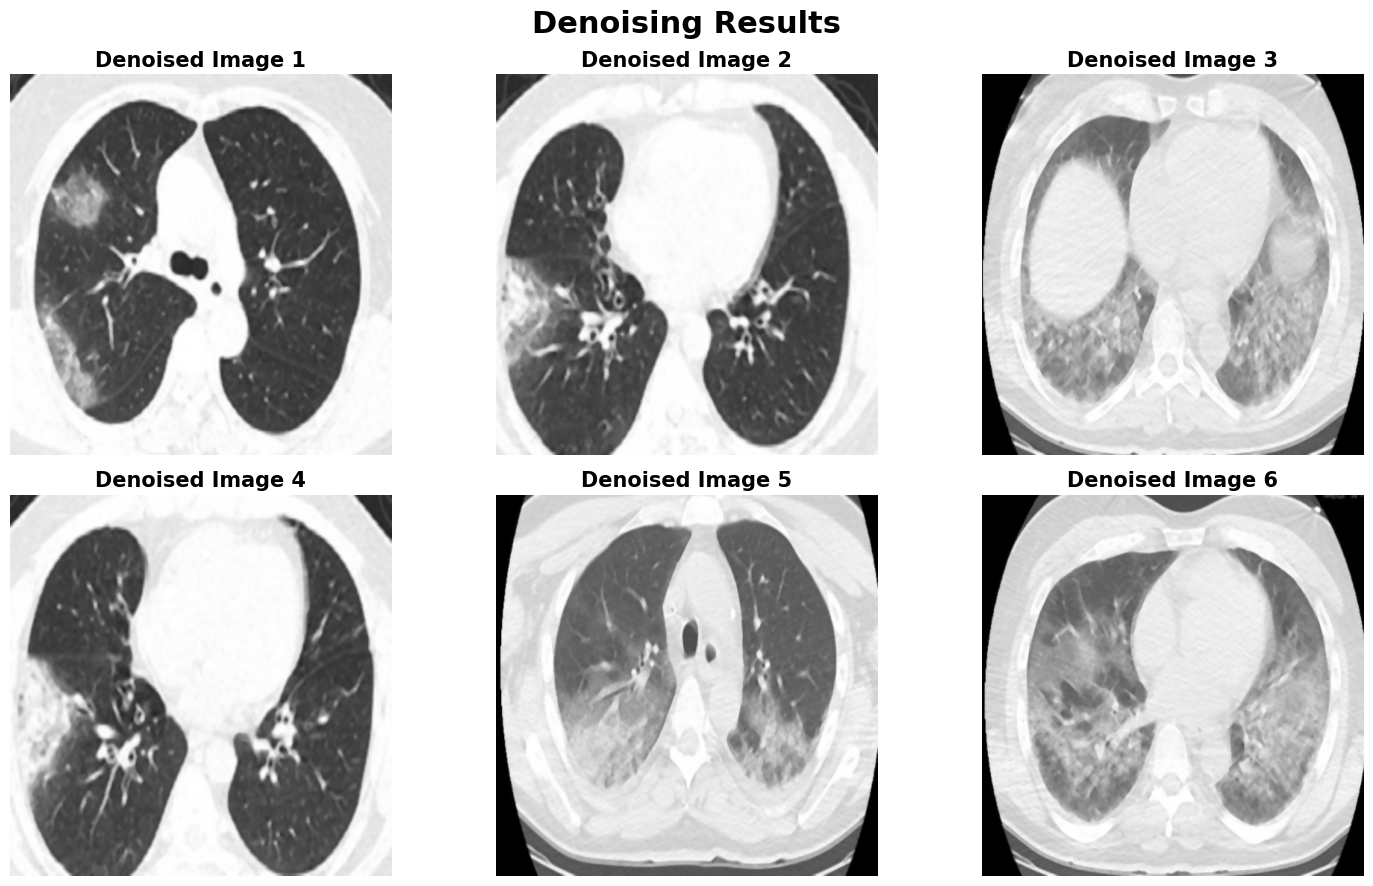

In [11]:
# ================================================================
# CELL 9: DENOISING VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i in range(len(images)):

    axes[i].imshow(
        denoised_images[i]
    )

    axes[i].set_title(
        f"Denoised Image {i+1}",
        fontsize=15,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Denoising Results",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [12]:
# ================================================================
# CELL 10: INTENSITY NORMALIZATION
# ================================================================

def normalize_image(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(
        gray
    )

    normalized = cv2.normalize(
        enhanced,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return normalized


normalized_images = []


for i, img in enumerate(
    denoised_images
):

    normalized = normalize_image(
        img
    )

    normalized_images.append(
        normalized
    )

    cv2.imwrite(
        os.path.join(
            DIRS["normalized"],
            f"image_{i+1}_normalized.png"
        ),
        normalized
    )


print("Normalization completed.")

Normalization completed.


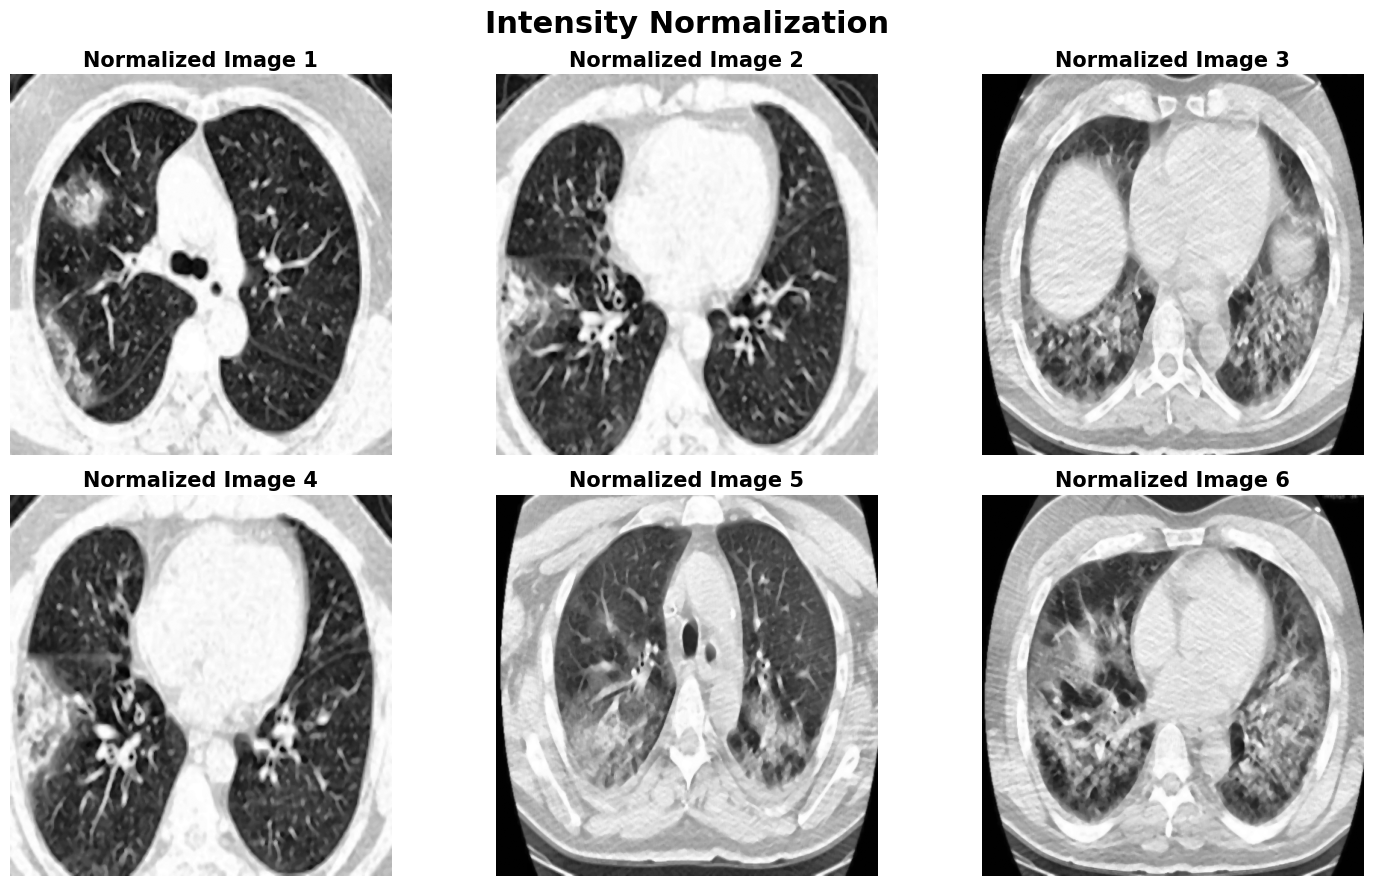

In [13]:
# ================================================================
# CELL 11: NORMALIZATION VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, img in enumerate(
    normalized_images
):

    axes[i].imshow(
        img,
        cmap="gray"
    )

    axes[i].set_title(
        f"Normalized Image {i+1}",
        fontsize=15,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Intensity Normalization",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [14]:
# ================================================================
# CELL 12: LUNG SEGMENTATION
# ================================================================

def segment_lungs(gray):

    # ------------------------------------------------------------
    # Gaussian smoothing
    # ------------------------------------------------------------

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )


    # ------------------------------------------------------------
    # Otsu threshold
    # ------------------------------------------------------------

    threshold = threshold_otsu(
        blur
    )

    binary = (
        blur < threshold
    )


    # ------------------------------------------------------------
    # Remove small objects
    # ------------------------------------------------------------

    binary = morphology.remove_small_objects(
        binary,
        min_size=500
    )


    # ------------------------------------------------------------
    # Fill holes
    # ------------------------------------------------------------

    binary = morphology.remove_small_holes(
        binary,
        area_threshold=1000
    )


    mask = (
        binary.astype(np.uint8)
        * 255
    )


    # ------------------------------------------------------------
    # Morphological operations
    # ------------------------------------------------------------

    kernel = np.ones(
        (7, 7),
        np.uint8
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )


    # ------------------------------------------------------------
    # Connected components
    # ------------------------------------------------------------

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )


    if num_labels > 1:

        areas = stats[
            1:,
            cv2.CC_STAT_AREA
        ]

        # Select up to two largest components
        order = np.argsort(areas)[::-1]

        selected = order[
            :min(2, len(order))
        ] + 1

        clean_mask = np.zeros_like(
            mask
        )

        for label in selected:

            clean_mask[
                labels == label
            ] = 255

        mask = clean_mask


    return mask


lung_masks = []


for i, img in enumerate(
    normalized_images
):

    mask = segment_lungs(
        img
    )

    lung_masks.append(
        mask
    )

    cv2.imwrite(
        os.path.join(
            DIRS["masks"],
            f"image_{i+1}_lung_mask.png"
        ),
        mask
    )


print("Lung segmentation completed.")

Lung segmentation completed.


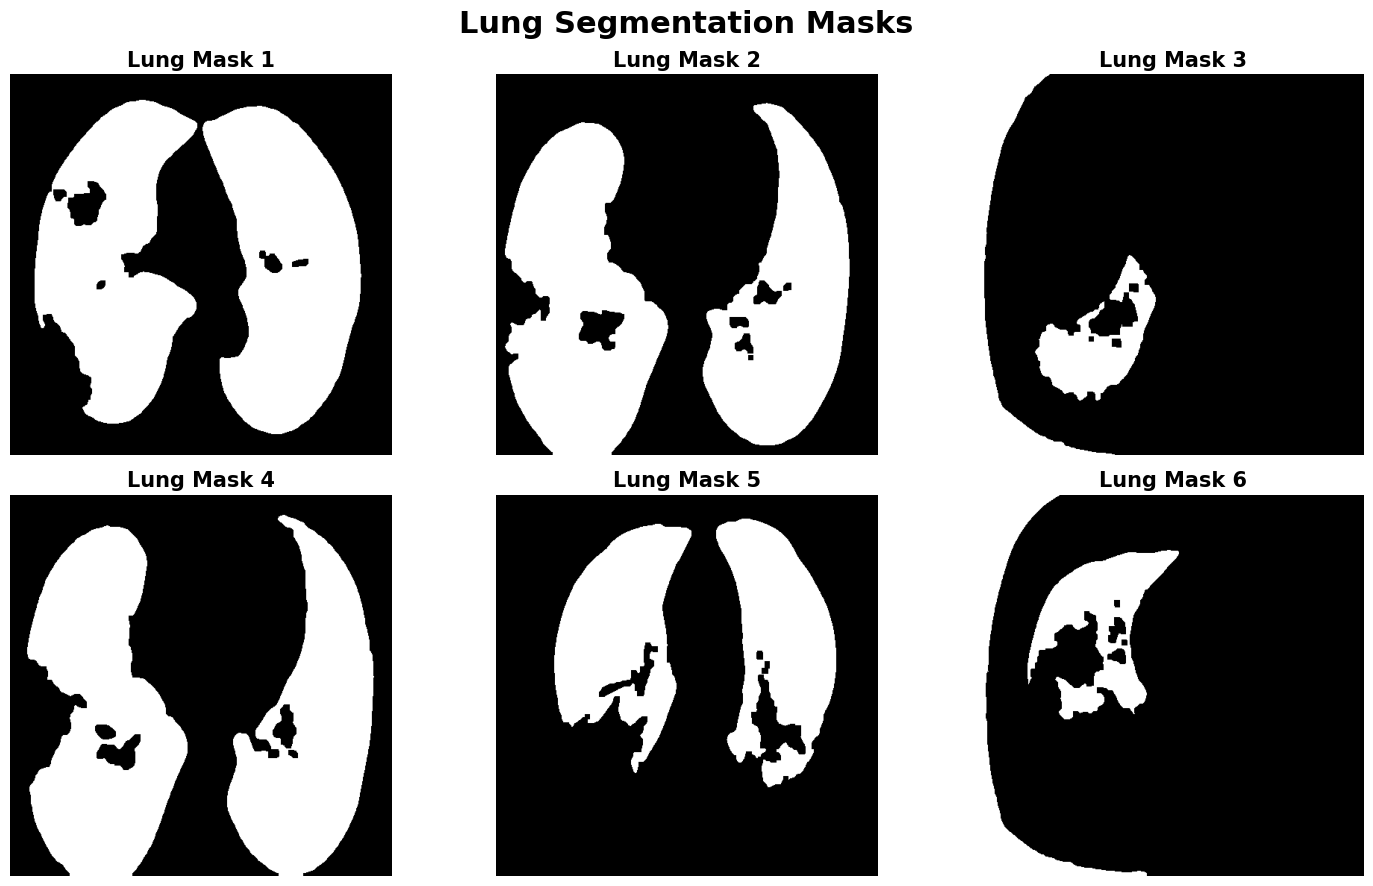

In [15]:
# ================================================================
# CELL 13: LUNG MASK VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, mask in enumerate(
    lung_masks
):

    axes[i].imshow(
        mask,
        cmap="gray"
    )

    axes[i].set_title(
        f"Lung Mask {i+1}",
        fontsize=15,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Lung Segmentation Masks",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [16]:
# ================================================================
# CELL 14: SEGMENTED LUNG REGION
# ================================================================

segmented_images = []


for i in range(
    len(normalized_images)
):

    segmented = cv2.bitwise_and(
        normalized_images[i],
        normalized_images[i],
        mask=lung_masks[i]
    )

    segmented_images.append(
        segmented
    )

    cv2.imwrite(
        os.path.join(
            DIRS["segmented"],
            f"image_{i+1}_segmented.png"
        ),
        segmented
    )


print(
    "Segmented lung images saved."
)

Segmented lung images saved.


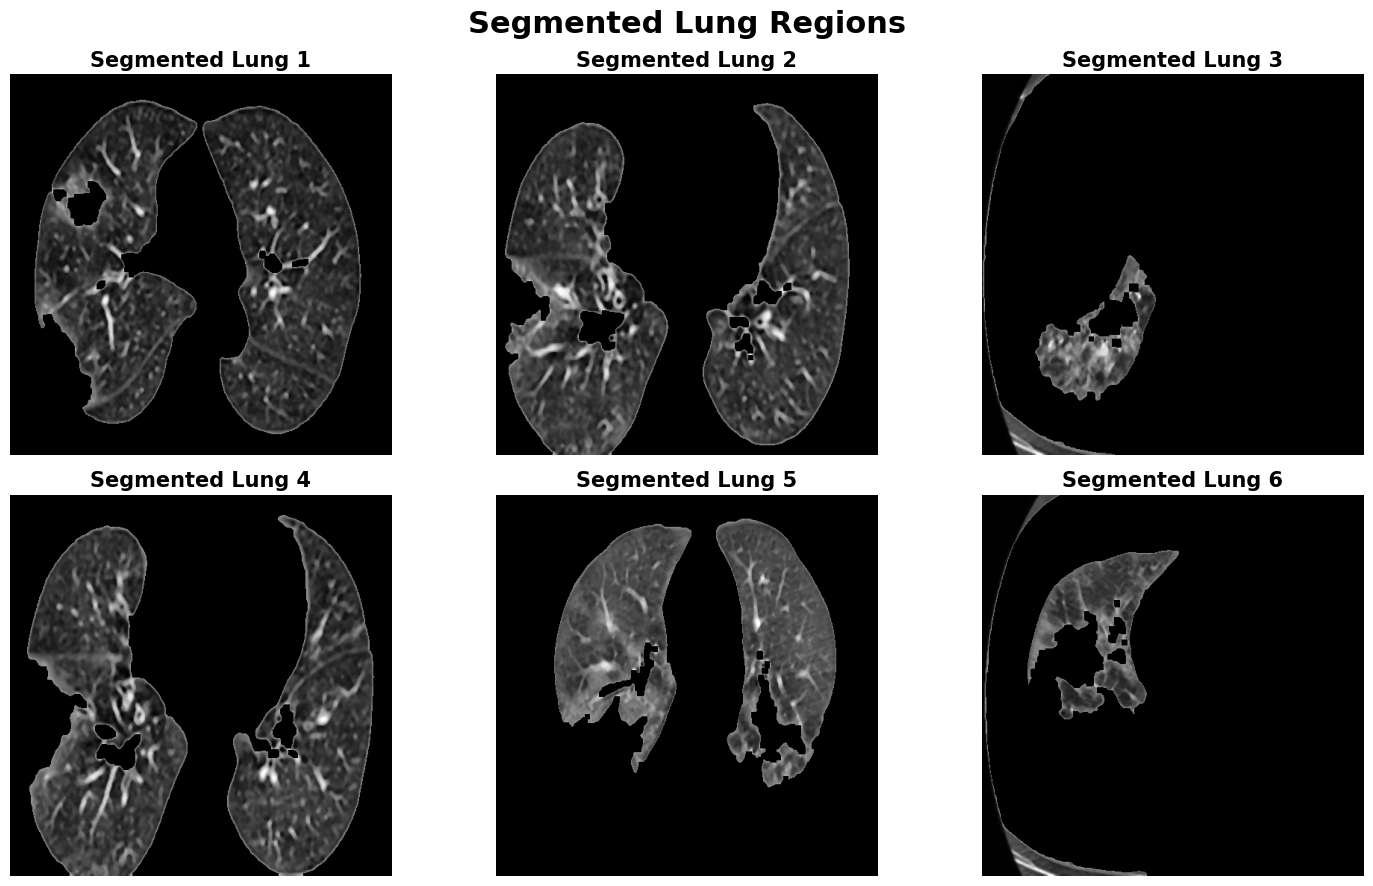

In [17]:
# ================================================================
# CELL 15: SEGMENTED LUNG VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, img in enumerate(
    segmented_images
):

    axes[i].imshow(
        img,
        cmap="gray"
    )

    axes[i].set_title(
        f"Segmented Lung {i+1}",
        fontsize=15,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Segmented Lung Regions",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

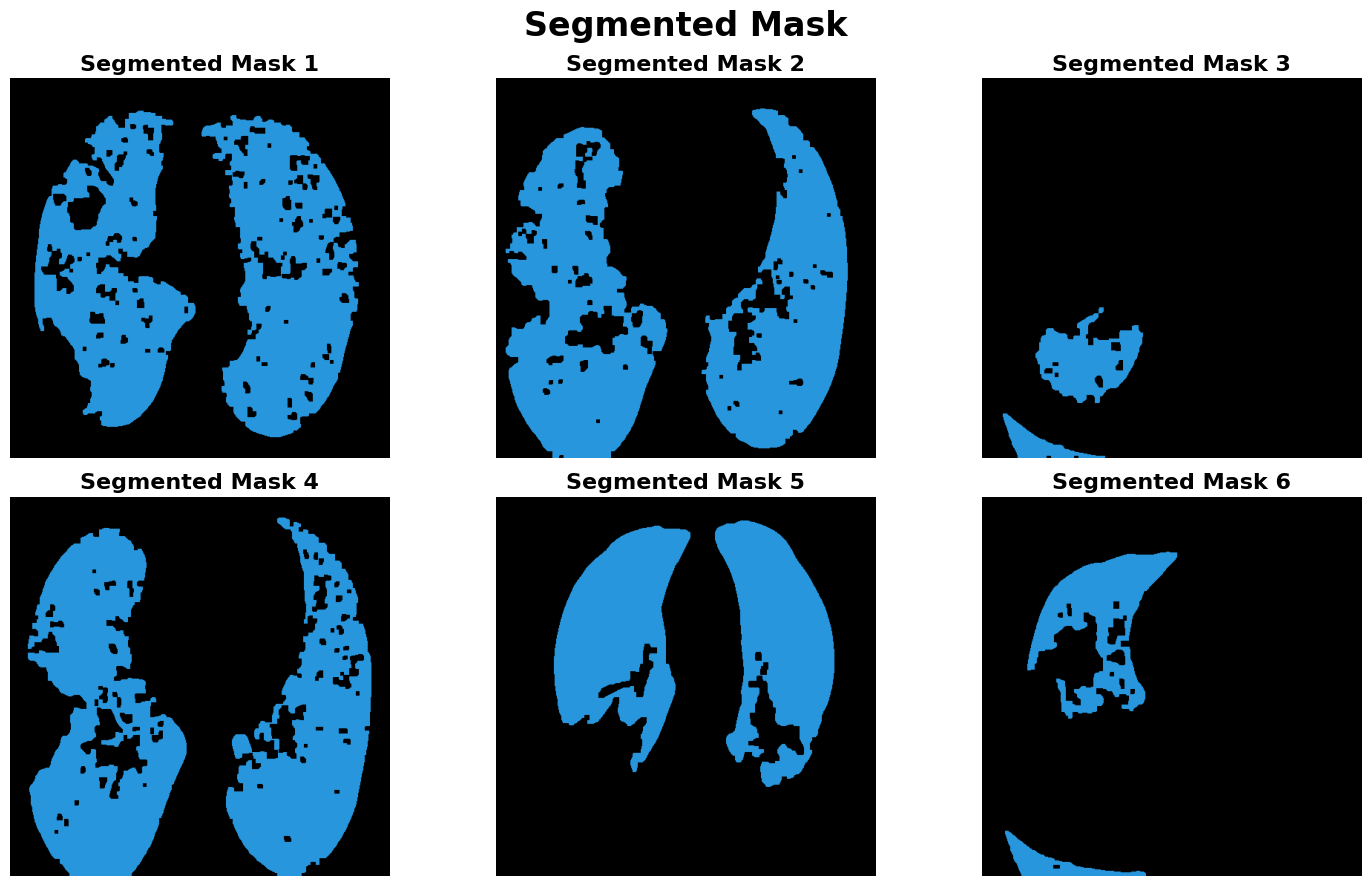

In [40]:
# ================================================================
# SEGMENTED MASK PROCESS
# INPUT  : segmented_images
# OUTPUT : colored segmented masks for all 6 images
# ================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

segmented_masks = []

for i, img in enumerate(segmented_images):

    # ------------------------------------------------------------
    # Convert to grayscale if required
    # ------------------------------------------------------------

    if len(img.shape) == 3:
        gray = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2GRAY
        )
    else:
        gray = img.copy()


    # ------------------------------------------------------------
    # Normalize
    # ------------------------------------------------------------

    gray = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    # ------------------------------------------------------------
    # Threshold
    # ------------------------------------------------------------

    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )


    # ------------------------------------------------------------
    # Morphological cleaning
    # ------------------------------------------------------------

    kernel = np.ones(
        (5, 5),
        np.uint8
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )


    # ------------------------------------------------------------
    # Keep largest connected regions
    # ------------------------------------------------------------

    num_labels, labels_img, stats, _ = \
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )

    clean_mask = np.zeros_like(mask)

    if num_labels > 1:

        areas = stats[
            1:,
            cv2.CC_STAT_AREA
        ]

        largest = np.argsort(
            areas
        )[::-1]

        # Keep up to 2 largest regions
        for idx in largest[:2]:

            label_id = idx + 1

            clean_mask[
                labels_img == label_id
            ] = 255


    mask = clean_mask


    # ------------------------------------------------------------
    # Create colored segmented mask
    # ------------------------------------------------------------

    color_mask = np.zeros(
        (
            mask.shape[0],
            mask.shape[1],
            3
        ),
        dtype=np.uint8
    )

    # Lung/segmented region
    color_mask[
        mask > 0
    ] = [
        40,   # R
        150,  # G
        220   # B
    ]


    segmented_masks.append(
        color_mask
    )


# ================================================================
# VISUALIZE ALL 6 SEGMENTED MASKS
# ================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, mask in enumerate(
    segmented_masks
):

    axes[i].imshow(
        mask
    )

    axes[i].set_title(
        f"Segmented Mask {i+1}",
        fontsize=16,
        fontweight="bold"
    )

    axes[i].axis("off")


plt.suptitle(
    "Segmented Mask",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

MULTI-SCALE VISUALIZATION
Total images: 6
Scales: [32, 64, 128, 224]


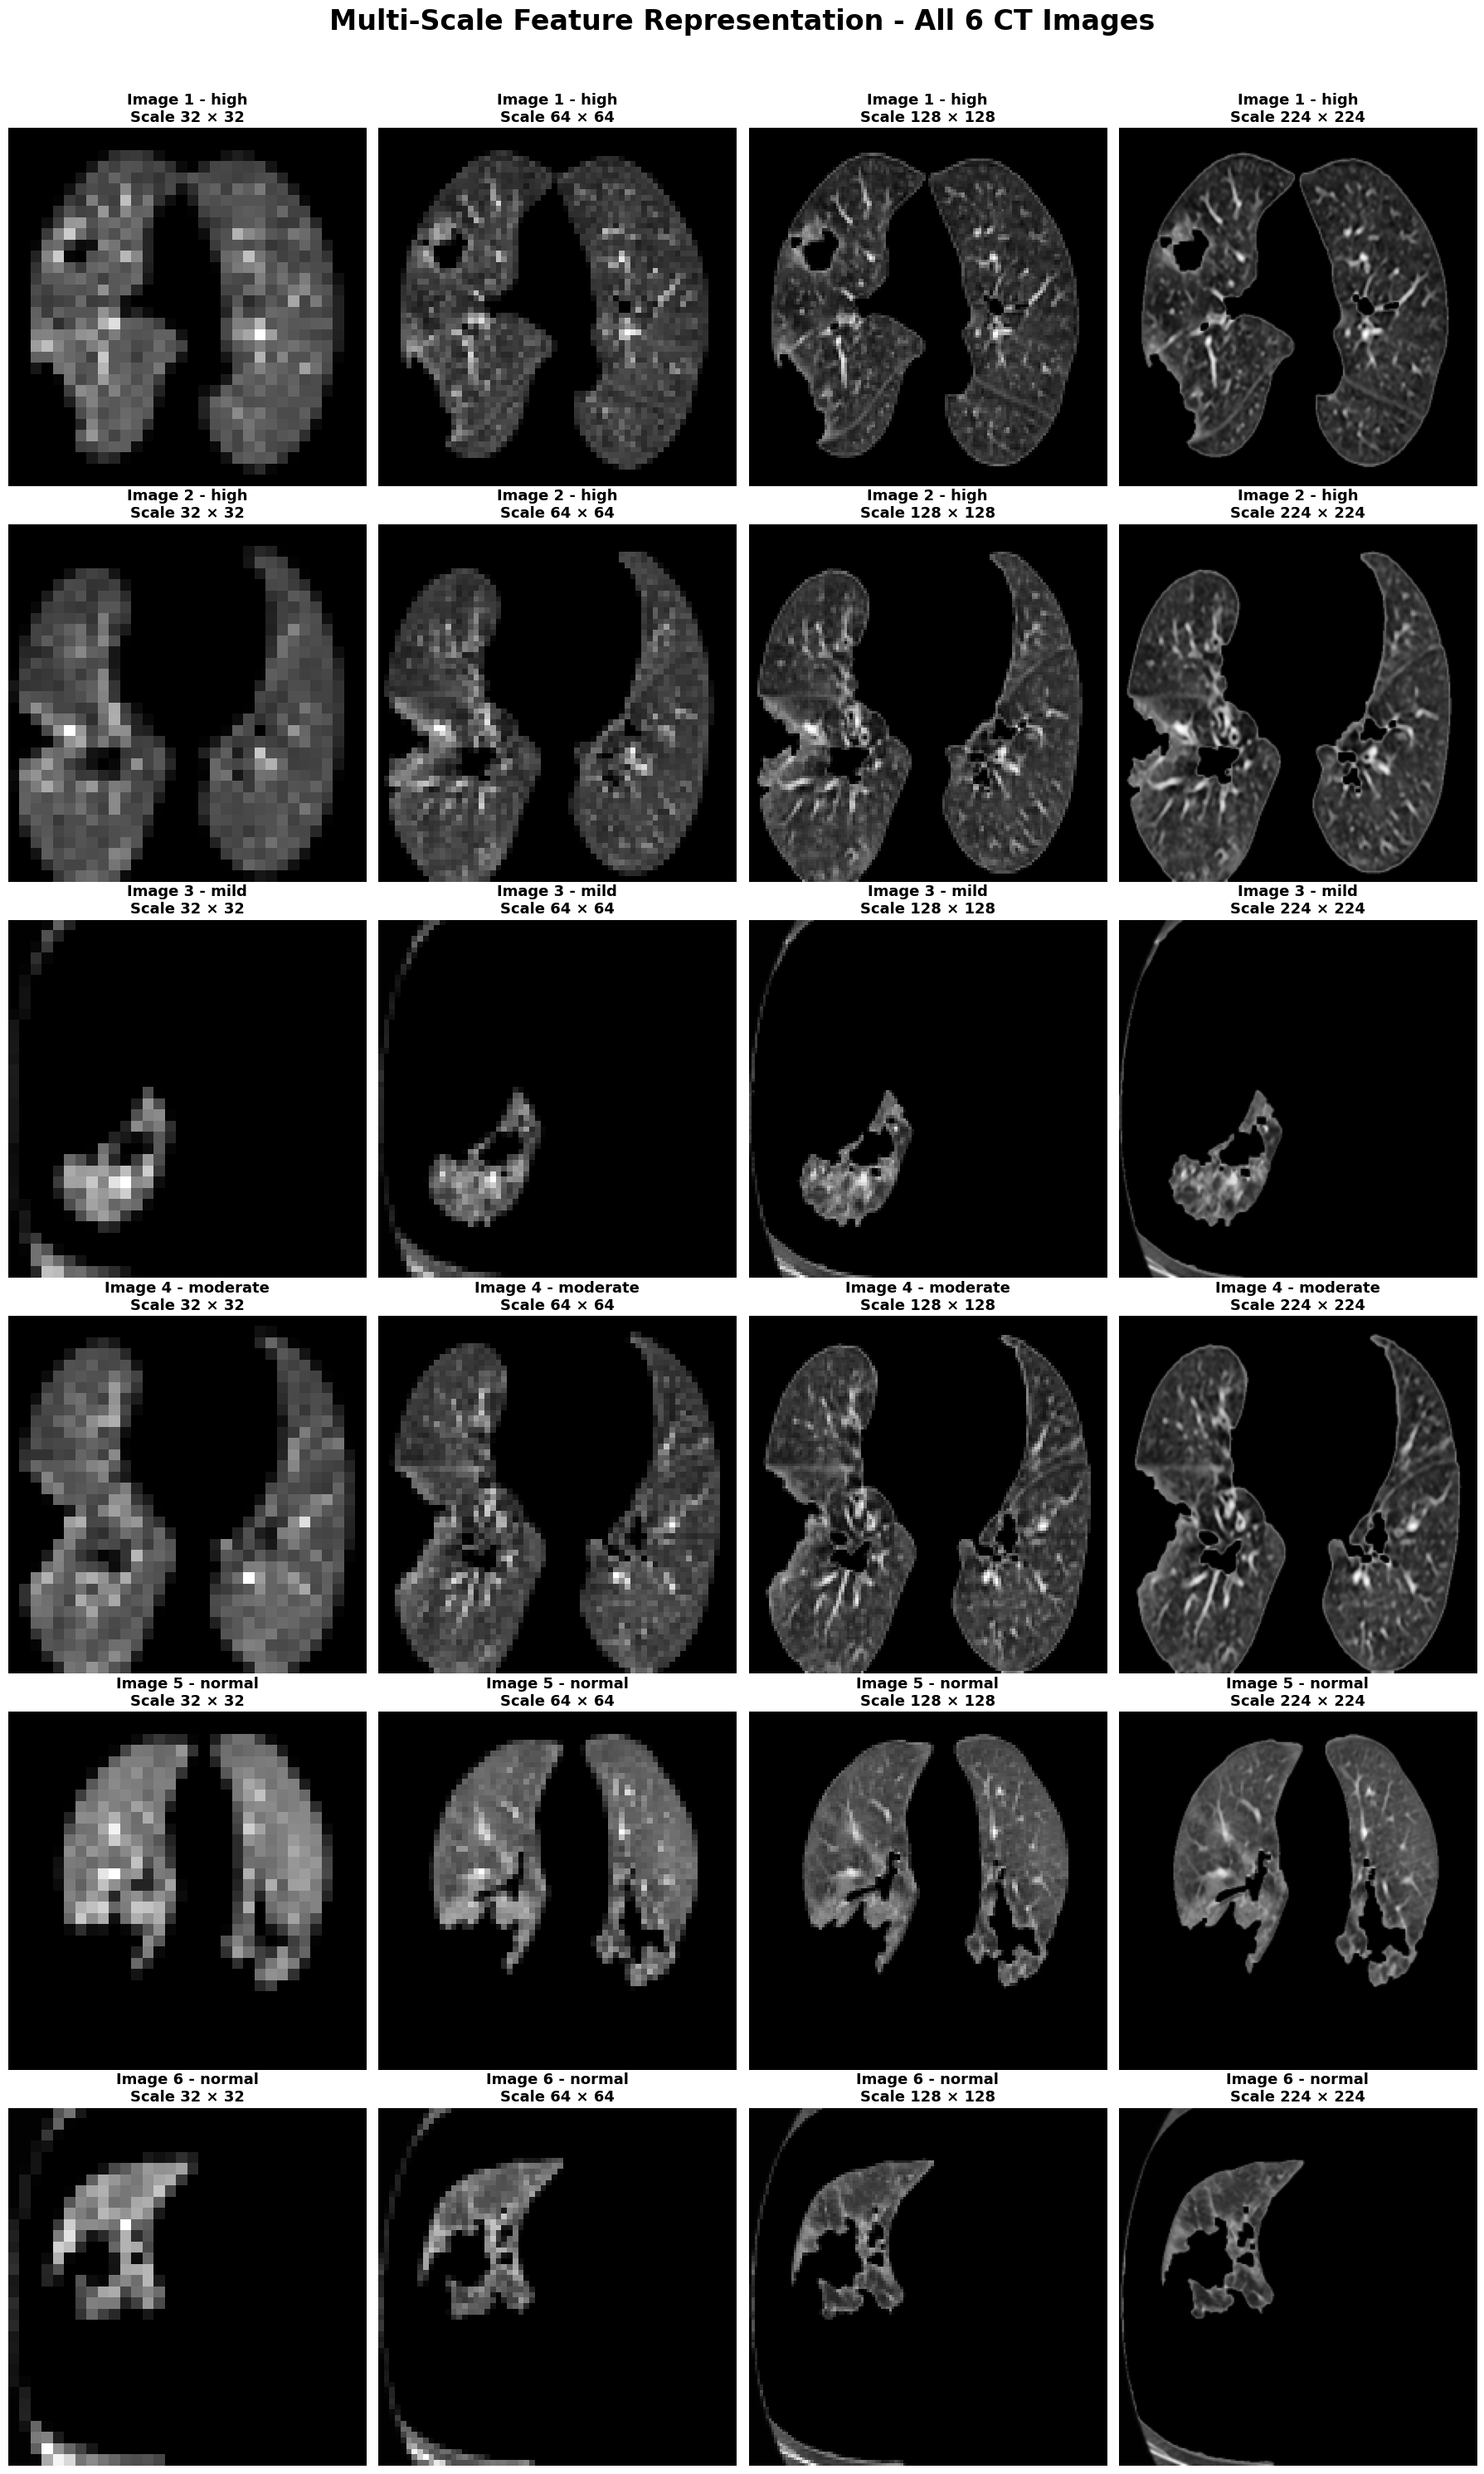

In [36]:
# ================================================================
# CELL 18: MULTI-SCALE VISUALIZATION FOR ALL 6 IMAGES
# ================================================================

sizes = [
    32,
    64,
    128,
    224
]

N_IMAGES = len(segmented_images)

print("=" * 70)
print("MULTI-SCALE VISUALIZATION")
print("=" * 70)

print("Total images:", N_IMAGES)
print("Scales:", sizes)


# ================================================================
# CREATE FIGURE
# 6 images × 4 scales
# ================================================================

fig, axes = plt.subplots(
    N_IMAGES,
    len(sizes),
    figsize=(18, 5 * N_IMAGES)
)


# Make sure axes is always 2D
axes = np.asarray(axes)

if N_IMAGES == 1:
    axes = axes.reshape(1, -1)


# ================================================================
# PROCESS ALL IMAGES
# ================================================================

for image_idx in range(N_IMAGES):

    sample = segmented_images[image_idx]


    # Get original class
    image_class = labels[image_idx]


    for scale_idx, size in enumerate(sizes):

        # --------------------------------------------------------
        # Resize segmented image
        # --------------------------------------------------------

        resized = cv2.resize(
            sample,
            (size, size),
            interpolation=cv2.INTER_AREA
        )


        # --------------------------------------------------------
        # Display
        # --------------------------------------------------------

        axes[
            image_idx,
            scale_idx
        ].imshow(
            resized,
            cmap="gray"
        )


        # --------------------------------------------------------
        # Title
        # --------------------------------------------------------

        axes[
            image_idx,
            scale_idx
        ].set_title(
            f"Image {image_idx + 1} - "
            f"{image_class}\n"
            f"Scale {size} × {size}",
            fontsize=13,
            fontweight="bold"
        )


        axes[
            image_idx,
            scale_idx
        ].axis("off")


# ================================================================
# ROW LABELS
# ================================================================

for image_idx in range(N_IMAGES):

    axes[
        image_idx,
        0
    ].set_ylabel(
        f"Image {image_idx + 1}",
        fontsize=16,
        fontweight="bold",
        rotation=90,
        labelpad=20
    )


# ================================================================
# MAIN TITLE
# ================================================================

plt.suptitle(
    "Multi-Scale Feature Representation - All 6 CT Images",
    fontsize=24,
    fontweight="bold",
    y=0.995
)


# ================================================================
# COLUMN LABELS
# ================================================================

for scale_idx, size in enumerate(sizes):

    axes[
        0,
        scale_idx
    ].set_xlabel(
        f"{size} × {size}",
        fontsize=14,
        fontweight="bold"
    )


# ================================================================
# LAYOUT
# ================================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.show()

In [37]:
# ================================================================
# MULTI-SCALE FEATURE EXTRACTION FOR ALL 6 IMAGES
# ================================================================

sizes = [32, 64, 128, 224]

all_multiscale_features = []

for image_idx, sample in enumerate(segmented_images):

    image_features = []

    for size in sizes:

        resized = cv2.resize(
            sample,
            (size, size),
            interpolation=cv2.INTER_AREA
        )

        feature = (
            resized.astype(np.float32) / 255.0
        )

        image_features.append(
            feature.flatten()
        )

    image_features = np.concatenate(
        image_features
    )

    all_multiscale_features.append(
        image_features
    )


all_multiscale_features = np.asarray(
    all_multiscale_features,
    dtype=np.float32
)


print(
    "All-image multi-scale feature shape:",
    all_multiscale_features.shape
)


np.save(
    os.path.join(
        DIRS["features"],
        "all_6_images_multiscale_features.npy"
    ),
    all_multiscale_features
)


print(
    "Saved:",
    os.path.join(
        DIRS["features"],
        "all_6_images_multiscale_features.npy"
    )
)

All-image multi-scale feature shape: (6, 71680)
Saved: /content/drive/MyDrive/cancer_pipeline/05_features/all_6_images_multiscale_features.npy


In [21]:
# ================================================================
# CELL 19: DINO-v2 FEATURE EXTRACTOR
# ================================================================

from transformers import AutoImageProcessor, AutoModel

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


DINO_MODEL = "facebook/dinov2-small"


processor = AutoImageProcessor.from_pretrained(
    DINO_MODEL
)


dino_model = AutoModel.from_pretrained(
    DINO_MODEL
)


dino_model = dino_model.to(
    device
)


dino_model.eval()


print(
    "DINO-v2 loaded successfully."
)

Device: cpu


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINO-v2 loaded successfully.


In [22]:
# ================================================================
# CELL 20: DINO-v2 FEATURE EXTRACTION
# ================================================================

dino_features = []


with torch.no_grad():

    for img in tqdm(
        segmented_images,
        desc="DINO-v2 extraction"
    ):

        # Convert grayscale to RGB
        rgb = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        pil_img = Image.fromarray(
            rgb
        )


        inputs = processor(
            images=pil_img,
            return_tensors="pt"
        )


        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }


        outputs = dino_model(
            **inputs
        )


        # CLS token
        embedding = outputs.last_hidden_state[
            :, 0, :
        ]


        embedding = embedding.cpu().numpy().flatten()


        dino_features.append(
            embedding
        )


dino_features = np.array(
    dino_features,
    dtype=np.float32
)


print(
    "DINO feature shape:",
    dino_features.shape
)


np.save(
    os.path.join(
        DIRS["embeddings"],
        "dino_v2_embeddings.npy"
    ),
    dino_features
)

DINO-v2 extraction: 100%|██████████| 6/6 [00:05<00:00,  1.05it/s]

DINO feature shape: (6, 384)


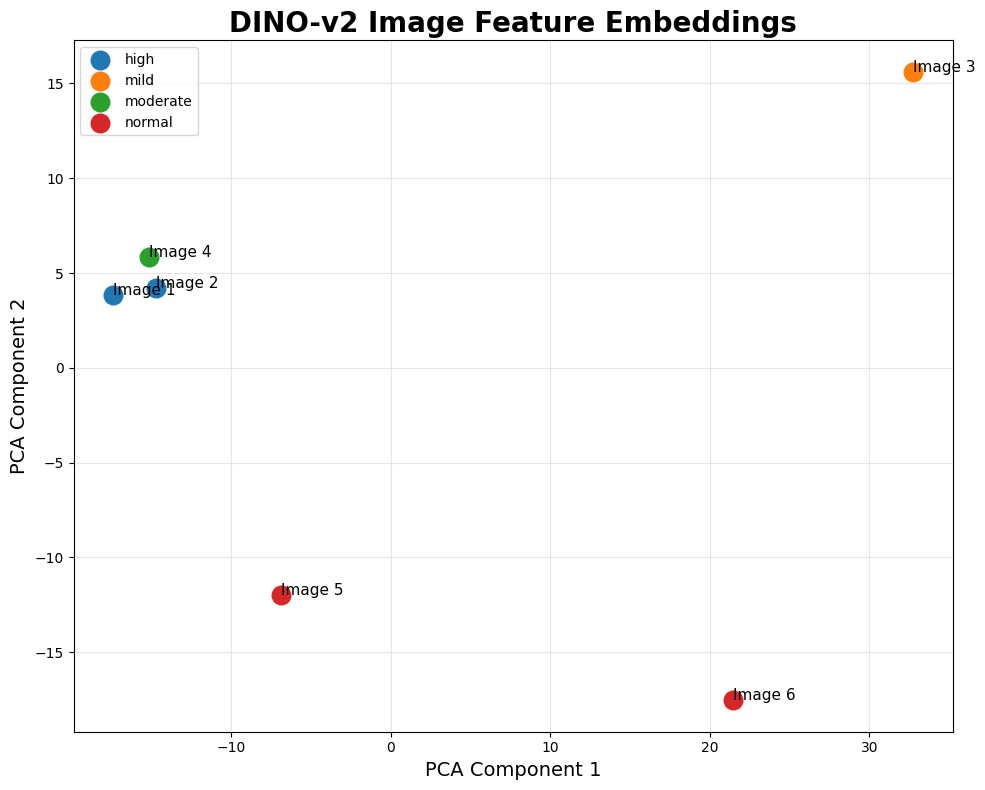

In [23]:
# ================================================================
# CELL 21: DINO-v2 EMBEDDING VISUALIZATION
# ================================================================

pca = PCA(
    n_components=2
)


embedding_2d = pca.fit_transform(
    dino_features
)


labels = [
    os.path.basename(
        os.path.dirname(path)
    )
    for path in image_paths
]


plt.figure(
    figsize=(10, 8)
)


unique_labels = list(
    dict.fromkeys(labels)
)


for label in unique_labels:

    indices = [
        i
        for i, x in enumerate(labels)
        if x == label
    ]

    plt.scatter(
        embedding_2d[indices, 0],
        embedding_2d[indices, 1],
        s=180,
        label=label
    )


for i in range(
    len(image_paths)
):

    plt.annotate(
        f"Image {i+1}",
        (
            embedding_2d[i, 0],
            embedding_2d[i, 1]
        ),
        fontsize=11
    )


plt.title(
    "DINO-v2 Image Feature Embeddings",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "PCA Component 1",
    fontsize=14
)

plt.ylabel(
    "PCA Component 2",
    fontsize=14
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

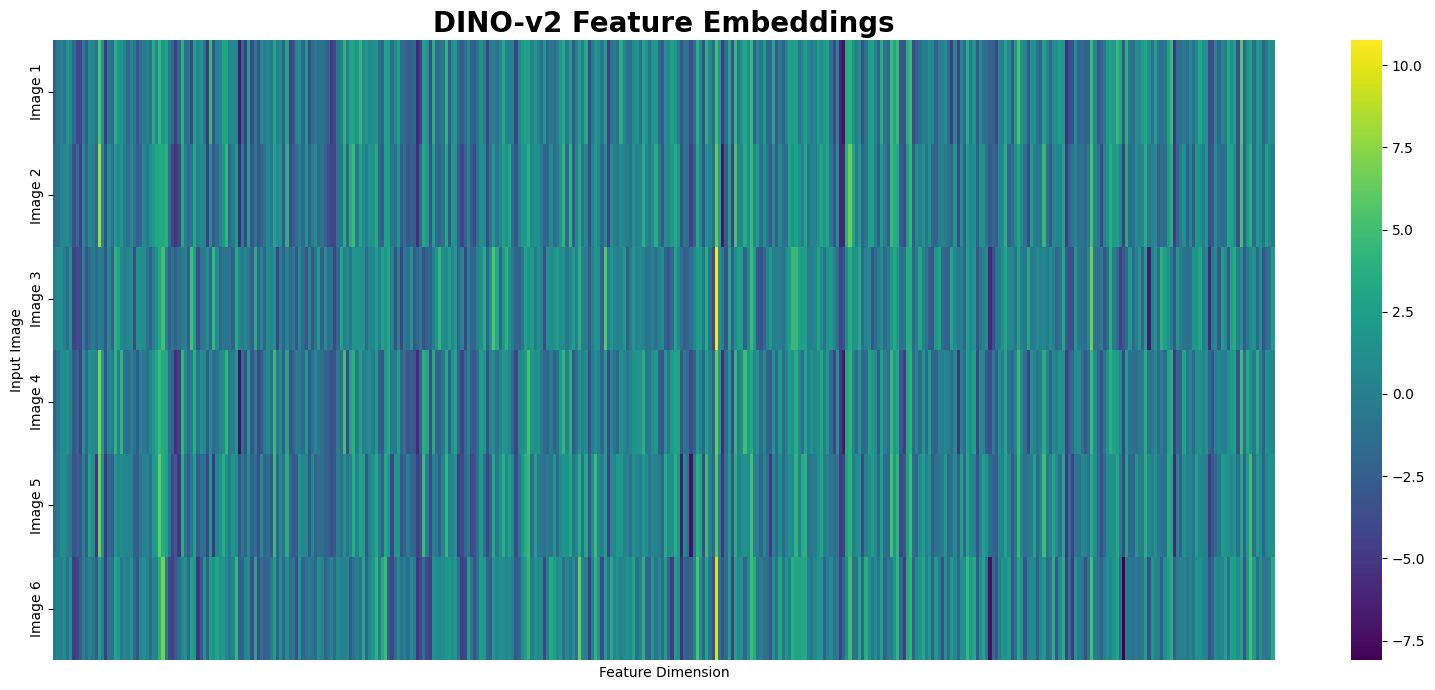

In [24]:
# ================================================================
# CELL 22: FEATURE EMBEDDING HEATMAP
# ================================================================

plt.figure(
    figsize=(16, 7)
)

sns.heatmap(
    dino_features,
    cmap="viridis",
    xticklabels=False,
    yticklabels=[
        f"Image {i+1}"
        for i in range(len(image_paths))
    ]
)

plt.title(
    "DINO-v2 Feature Embeddings",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Feature Dimension"
)

plt.ylabel(
    "Input Image"
)

plt.tight_layout()

plt.show()

In [27]:
# ================================================================
# CELL 25: COMBINE MULTI-SCALE + DINO FEATURES
# ================================================================

combined_features = np.concatenate(
    [
        multiscale_features,
        dino_features
    ],
    axis=1
)


print(
    "Combined feature shape:",
    combined_features.shape
)


np.save(
    os.path.join(
        DIRS["embeddings"],
        "combined_image_embeddings.npy"
    ),
    combined_features
)

Combined feature shape: (6, 72064)


In [28]:
# ================================================================
# CELL 26: CLINICAL DATA
# ================================================================

CLINICAL_CSV = (
    "/content/drive/MyDrive/"
    "cancer_dataset/clinical_data.csv"
)


if os.path.exists(CLINICAL_CSV):

    clinical_df = pd.read_csv(
        CLINICAL_CSV
    )

    print(
        "Clinical data loaded."
    )

    display(
        clinical_df.head()
    )

else:

    print(
        "Clinical CSV not found."
    )

    print(
        "Upload/provide your clinical CSV "
        "before running the clinical fusion stage."
    )

Clinical CSV not found.
Upload/provide your clinical CSV before running the clinical fusion stage.


In [29]:
# ================================================================
# CELL 27: CROSS-MODAL FUSION TRANSFORMER
# ================================================================

class CrossModalFusionTransformer(
    nn.Module
):

    def __init__(
        self,
        image_dim,
        clinical_dim,
        hidden_dim=256,
        heads=4,
        layers=2
    ):

        super().__init__()


        self.image_projection = nn.Linear(
            image_dim,
            hidden_dim
        )


        self.clinical_projection = nn.Linear(
            clinical_dim,
            hidden_dim
        )


        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=heads,
            batch_first=True
        )


        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers
        )


        self.output_layer = nn.Linear(
            hidden_dim,
            hidden_dim
        )


    def forward(
        self,
        image_features,
        clinical_features
    ):

        image_token = self.image_projection(
            image_features
        ).unsqueeze(1)


        clinical_token = self.clinical_projection(
            clinical_features
        ).unsqueeze(1)


        tokens = torch.cat(
            [
                image_token,
                clinical_token
            ],
            dim=1
        )


        fused = self.transformer(
            tokens
        )


        fused = fused.mean(
            dim=1
        )


        output = self.output_layer(
            fused
        )


        return output


print(
    "Cross-modal Transformer defined."
)

Cross-modal Transformer defined.


In [31]:
# ================================================================
# CELL 29: GRAD-CAM MODEL
# ================================================================

grad_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

grad_model = grad_model.to(
    device
)

grad_model.eval()


target_layer = grad_model.layer4


activations = None
gradients = None


def forward_hook(
    module,
    input,
    output
):

    global activations

    activations = output


def backward_hook(
    module,
    grad_input,
    grad_output
):

    global gradients

    gradients = grad_output[0]


target_layer.register_forward_hook(
    forward_hook
)

target_layer.register_full_backward_hook(
    backward_hook
)


transform_cam = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (224, 224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [32]:
# ================================================================
# CELL 30: GENERATE GRAD-CAM
# ================================================================

def generate_gradcam(img):

    global activations
    global gradients


    x = transform_cam(
        img
    ).unsqueeze(0).to(
        device
    )


    grad_model.zero_grad()


    output = grad_model(
        x
    )


    # Use strongest predicted class
    class_index = output.argmax(
        dim=1
    ).item()


    score = output[
        0,
        class_index
    ]


    score.backward()


    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )


    cam = (
        weights * activations
    ).sum(
        dim=1
    ).squeeze()


    cam = torch.relu(
        cam
    )


    cam = cam.detach().cpu().numpy()


    cam = cv2.resize(
        cam,
        (
            img.shape[1],
            img.shape[0]
        )
    )


    cam -= cam.min()

    if cam.max() > 0:

        cam /= cam.max()


    return cam


print(
    "Grad-CAM function ready."
)

Grad-CAM function ready.


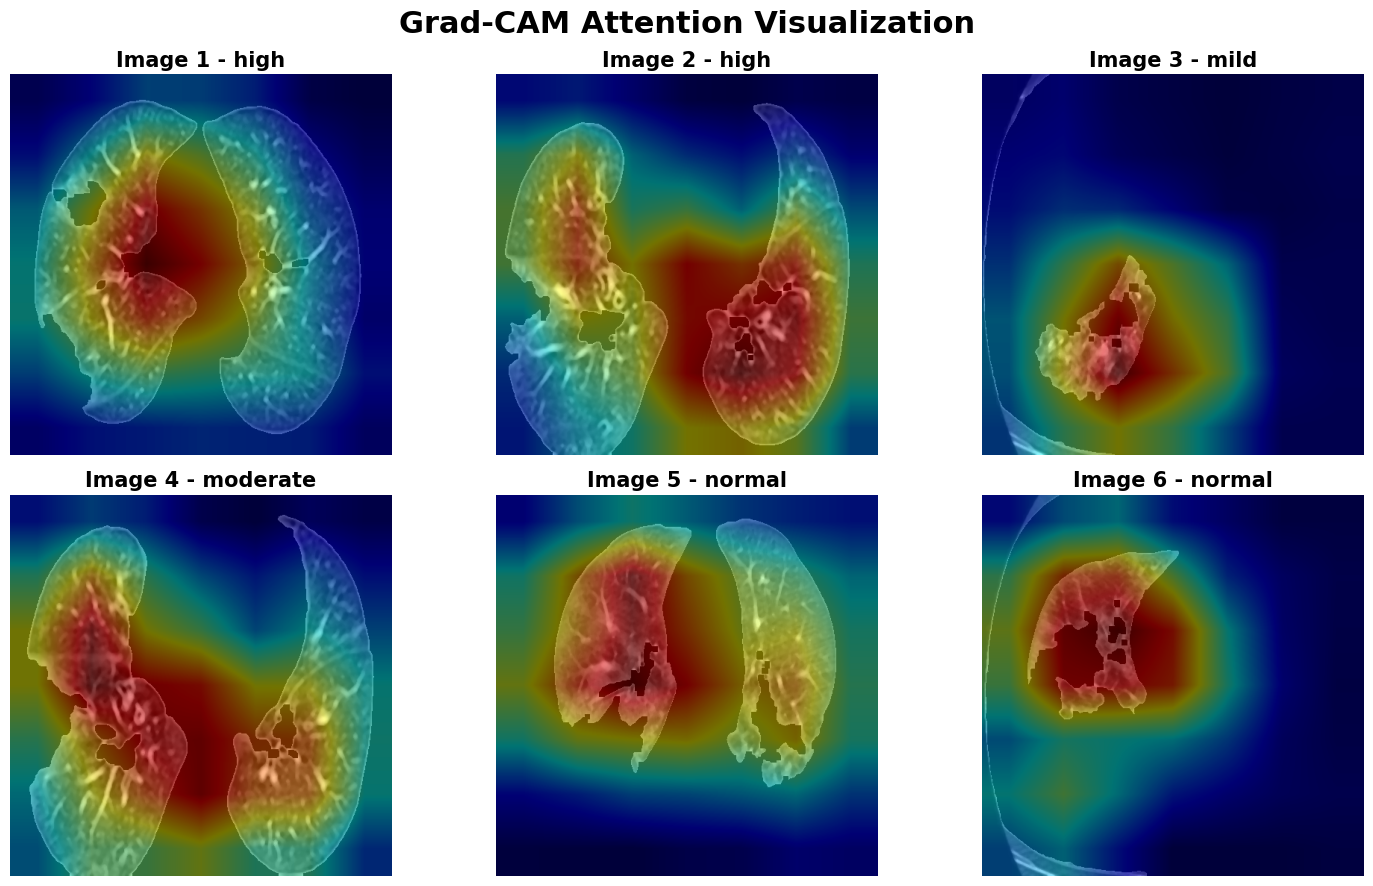

In [33]:
# ================================================================
# CELL 31: GRAD-CAM VISUALIZATION
# ================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, img in enumerate(
    segmented_images
):

    cam = generate_gradcam(
        img
    )


    heatmap = cv2.applyColorMap(
        np.uint8(
            255 * cam
        ),
        cv2.COLORMAP_JET
    )


    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )


    base = cv2.cvtColor(
        img,
        cv2.COLOR_GRAY2RGB
    )


    overlay = cv2.addWeighted(
        base,
        0.55,
        heatmap,
        0.45,
        0
    )


    axes[i].imshow(
        overlay
    )


    axes[i].set_title(
        f"Image {i+1} - {labels[i]}",
        fontsize=15,
        fontweight="bold"
    )


    axes[i].axis("off")


    cv2.imwrite(
        os.path.join(
            DIRS["gradcam"],
            f"image_{i+1}_gradcam.png"
        ),
        cv2.cvtColor(
            overlay,
            cv2.COLOR_RGB2BGR
        )
    )


plt.suptitle(
    "Grad-CAM Attention Visualization",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [43]:
# ================================================================
# CELL 33: FINAL RESULTS TABLE
# ================================================================

results_df = pd.DataFrame({

    "Image":
        [
            os.path.basename(x)
            for x in image_paths
        ],

    "Class":
        labels,

    "Image_Width":
        [x.shape[1] for x in images],

    "Image_Height":
        [x.shape[0] for x in images],

    "DINO_Feature_Dimension":
        [
            dino_features.shape[1]
        ] * len(images),

    "Combined_Feature_Dimension":
        [
            combined_features.shape[1]
        ] * len(images)
})


display(
    results_df
)


results_df.to_csv(
    os.path.join(
        DIRS["results"],
        "final_processing_results.csv"
    ),
    index=False
)


print(
    "\nResults saved successfully."
)

,Image,Class,Image_Width,Image_Height,DINO_Feature_Dimension,Combined_Feature_Dimension
0,Comparison-of-different-samples-for-2019-novel...,high,512,512,384,72064
1,Comparison-of-different-samples-for-2019-novel...,high,512,512,384,72064
2,1307.png,mild,512,512,384,72064
3,Comparison-of-different-samples-for-2019-novel...,moderate,512,512,384,72064
4,1305.png,normal,512,512,384,72064
5,1306.png,normal,512,512,384,72064



Results saved successfully.
